# Scratch baselines with SAM — CustomCNN, ResNet18, ViT
- Same preprocessing and schedule; SAM enabled (ρ: CNN/ResNet ~0.02–0.05, ViT ~0.2).

In [4]:
# Make sure Python can import the package by name:
import sys
from pathlib import Path

# If the notebook is inside notebooks/, add the parent (project root) to sys.path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("sys.path[0] =", sys.path[0])

# Now import from the package by name (ABSOLUTE import, no leading dot)
from src import (
    DataCfg, TrainCfg, build_dataloaders, get_device, set_seed,
    build_custom_cnn, build_resnet18, build_vit_scratch, build_vit_pretrained,
    train_model, evaluate, choose_threshold_by_min_recall,
    summarize_at_threshold, plot_curve, plot_two_series, diag_plots,
    add_result, result_registry
)

import numpy as np, torch, time
set_seed(42)
DEVICE = get_device(); DEVICE


sys.path[0] = /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning_2025/Deep-Learning-Project


device(type='mps')

In [6]:
DATASET_DIR = Path("../Data/chest_xray")  # <--- EDIT THIS PATH
data_cfg = DataCfg(dataset_dir=DATASET_DIR, image_size=224,
                   use_stratified_val=True, stratified_val_size=0.15,
                   batch_size=32, num_workers=0, pin_memory=True)

scratch_sam_cfg = TrainCfg(
    epochs=100, patience=15, monitor="va_auroc",
    base_lr=3e-4, weight_decay=0.3,
    clip_grad_norm=1.0, use_amp=False,
    use_sam=True,  sam_rho=0.2,    # global; each model sets its preferred rho below
    use_cosine=True, warmup_epochs=3, min_lr_mult=0.01,
    target_recall=0.95,
    llrd=False, head_lr_mult=10.0,
)

train_loader, val_loader, test_loader, info = build_dataloaders(
    data_cfg.dataset_dir, data_cfg.image_size, data_cfg.batch_size,
    data_cfg.num_workers, data_cfg.pin_memory,
    data_cfg.use_stratified_val, data_cfg.stratified_val_size
)
print("Classes:", info["classes"]); print("Lens:", info["n_train"], info["n_val"], info["n_test"])
arr = np.array(info["train_counts"], dtype=float); w = arr.sum()/(len(arr)*(arr+1e-9))
class_weights = torch.tensor(w, dtype=torch.float32).to(DEVICE)


Classes: ['NORMAL', 'PNEUMONIA']
Lens: 4447 785 624


[CustomCNN-scratch+SAM] epoch 01/100  tr_loss=0.4661  val_loss=1.9287  val_acc=0.3490  val_f1=0.2198  val_auroc=0.9299  (no_improve=0)
[CustomCNN-scratch+SAM] epoch 02/100  tr_loss=0.4337  val_loss=0.3363  val_acc=0.8522  val_f1=0.8928  val_auroc=0.9345  (no_improve=0)
[CustomCNN-scratch+SAM] epoch 03/100  tr_loss=0.4297  val_loss=0.3388  val_acc=0.8535  val_f1=0.8930  val_auroc=0.9340  (no_improve=1)
[CustomCNN-scratch+SAM] epoch 04/100  tr_loss=0.4224  val_loss=0.3551  val_acc=0.8484  val_f1=0.8897  val_auroc=0.9274  (no_improve=2)
[CustomCNN-scratch+SAM] epoch 05/100  tr_loss=0.4013  val_loss=0.3189  val_acc=0.8777  val_f1=0.9140  val_auroc=0.9366  (no_improve=0)
[CustomCNN-scratch+SAM] epoch 06/100  tr_loss=0.3955  val_loss=0.3134  val_acc=0.8599  val_f1=0.8978  val_auroc=0.9411  (no_improve=0)
[CustomCNN-scratch+SAM] epoch 07/100  tr_loss=0.3721  val_loss=0.3125  val_acc=0.8535  val_f1=0.8932  val_auroc=0.9394  (no_improve=1)
[CustomCNN-scratch+SAM] epoch 08/100  tr_loss=0.3865  v

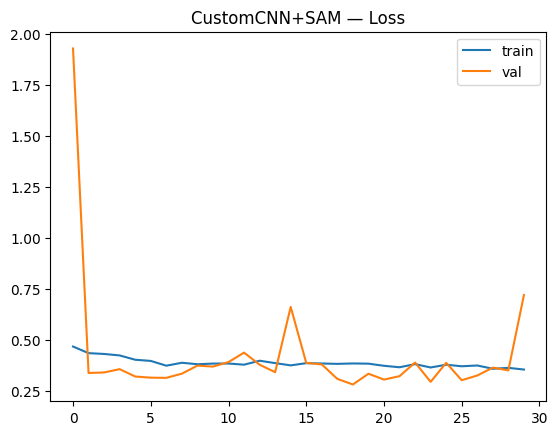

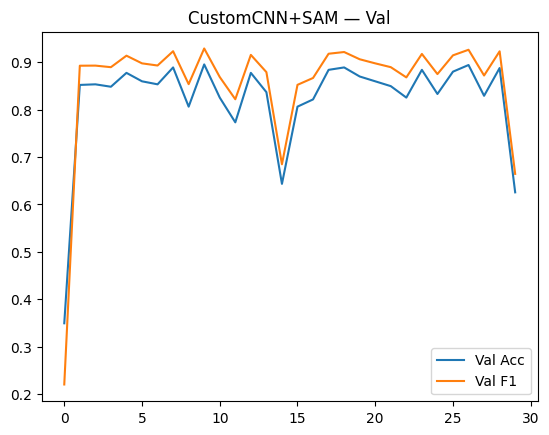

[CustomCNN-scratch+SAM @0.5] {'acc': 0.7212, 'precision': 0.9696, 'recall': 0.5718, 'f1': 0.7194, 'auroc': 0.9026, 'thr': 0.5}
[CustomCNN-scratch+SAM @Rec] {'acc': 0.625, 'precision': 0.625, 'recall': 1.0, 'f1': 0.7692, 'auroc': 0.9026, 'thr': 0.0002}


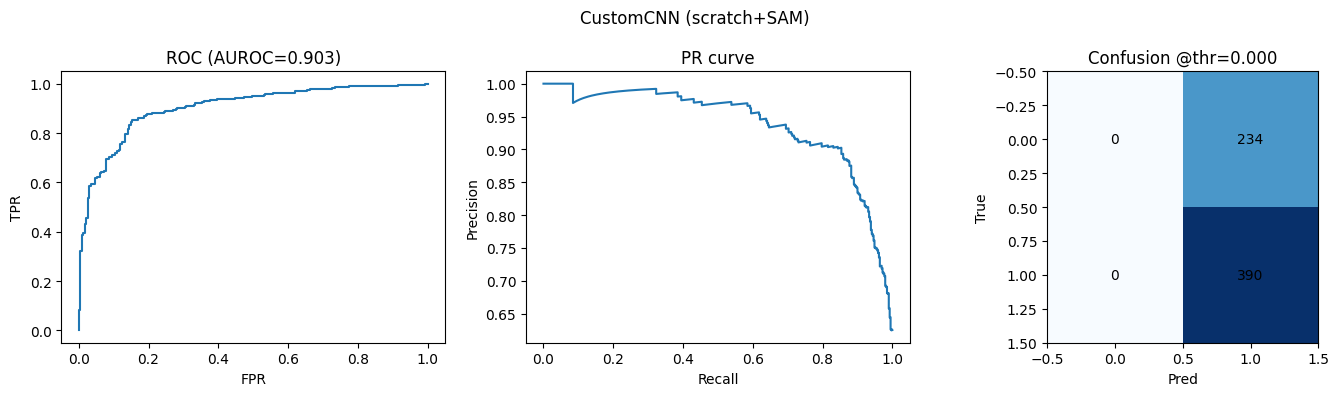

{'summary@0.5': {'acc': 0.7211538461538461,
  'precision': 0.9695652173913043,
  'recall': 0.5717948717948718,
  'f1': 0.7193548387096774,
  'auroc': 0.9026408064869604,
  'thr': 0.5},
 'summary@recall': {'acc': 0.625,
  'precision': 0.625,
  'recall': 1.0,
  'f1': 0.7692307692307693,
  'auroc': 0.9026408064869604,
  'thr': 0.00017857753846328706},
 'threshold': 0.00017857753846328706,
 'time_sec': 5791.3102850914,
 'params': 481698}

In [7]:
cfg = scratch_sam_cfg
cnn = build_custom_cnn(num_classes=2, width=32, dropout=0.0)
t0=time.time()
cnn_tr, cnn_hist, cnn_time = train_model(
    cnn, train_loader, val_loader, DEVICE, arch="custom_cnn",
    epochs=cfg.epochs, base_lr=0.1, weight_decay=1e-3, label_smoothing=0.0,
    use_sam=True, sam_rho=0.02,
    use_cosine=cfg.use_cosine, warmup_epochs=cfg.warmup_epochs, min_lr_mult=cfg.min_lr_mult,
    monitor=cfg.monitor, patience=cfg.patience, clip_grad_norm=cfg.clip_grad_norm,
    class_weights=class_weights, llrd=False, head_lr_mult=cfg.head_lr_mult, use_amp=cfg.use_amp,
    tag="CustomCNN-scratch+SAM"
); cnn_time=time.time()-t0
plot_curve(cnn_hist['tr_loss'], cnn_hist['va_loss'], "CustomCNN+SAM — Loss")
plot_two_series(cnn_hist['va_acc'], "Val Acc", cnn_hist['va_f1'], "Val F1", "CustomCNN+SAM — Val")
va=evaluate(cnn_tr, val_loader, DEVICE)
thr,rec,prec,f1=choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], cfg.target_recall)
te=evaluate(cnn_tr, test_loader, DEVICE)
sum_05=summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca=summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[CustomCNN-scratch+SAM @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[CustomCNN-scratch+SAM @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("CustomCNN (scratch+SAM)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("CustomCNN (scratch+SAM)", cnn_tr, sum_05, sum_reca, threshold=thr, time_sec=cnn_time)


[ResNet18-scratch+SAM] epoch 01/90  tr_loss=0.5673  val_loss=0.3136  val_acc=0.8242  val_f1=0.8663  val_auroc=0.9707  (no_improve=0)
[ResNet18-scratch+SAM] epoch 02/90  tr_loss=0.5151  val_loss=0.3088  val_acc=0.9325  val_f1=0.9552  val_auroc=0.9760  (no_improve=0)
[ResNet18-scratch+SAM] epoch 03/90  tr_loss=0.4531  val_loss=0.2951  val_acc=0.8803  val_f1=0.9139  val_auroc=0.9701  (no_improve=1)
[ResNet18-scratch+SAM] epoch 04/90  tr_loss=0.4687  val_loss=0.2742  val_acc=0.8688  val_f1=0.9052  val_auroc=0.9605  (no_improve=2)
[ResNet18-scratch+SAM] epoch 05/90  tr_loss=0.4005  val_loss=0.3544  val_acc=0.7631  val_f1=0.8121  val_auroc=0.9699  (no_improve=3)
[ResNet18-scratch+SAM] epoch 06/90  tr_loss=0.3842  val_loss=0.5296  val_acc=0.8726  val_f1=0.9199  val_auroc=0.9593  (no_improve=4)
[ResNet18-scratch+SAM] epoch 07/90  tr_loss=0.3847  val_loss=0.3731  val_acc=0.7299  val_f1=0.7801  val_auroc=0.9661  (no_improve=5)
[ResNet18-scratch+SAM] epoch 08/90  tr_loss=0.3738  val_loss=0.2195  

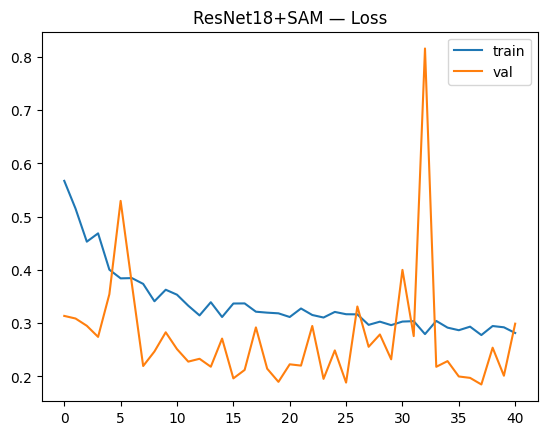

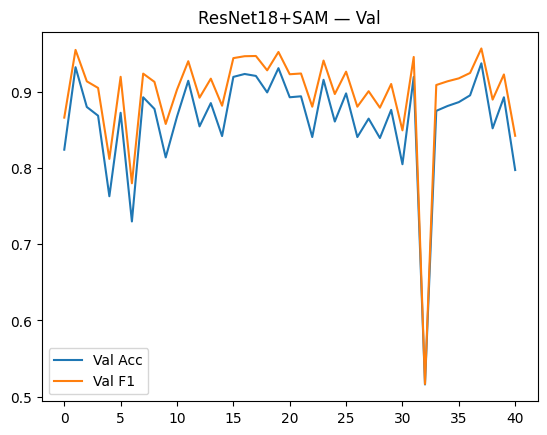

[ResNet18-scratch+SAM @0.5] {'acc': 0.8766, 'precision': 0.8922, 'recall': 0.9128, 'f1': 0.9024, 'auroc': 0.9334, 'thr': 0.5}
[ResNet18-scratch+SAM @Rec] {'acc': 0.625, 'precision': 0.625, 'recall': 1.0, 'f1': 0.7692, 'auroc': 0.9334, 'thr': 0.0003}


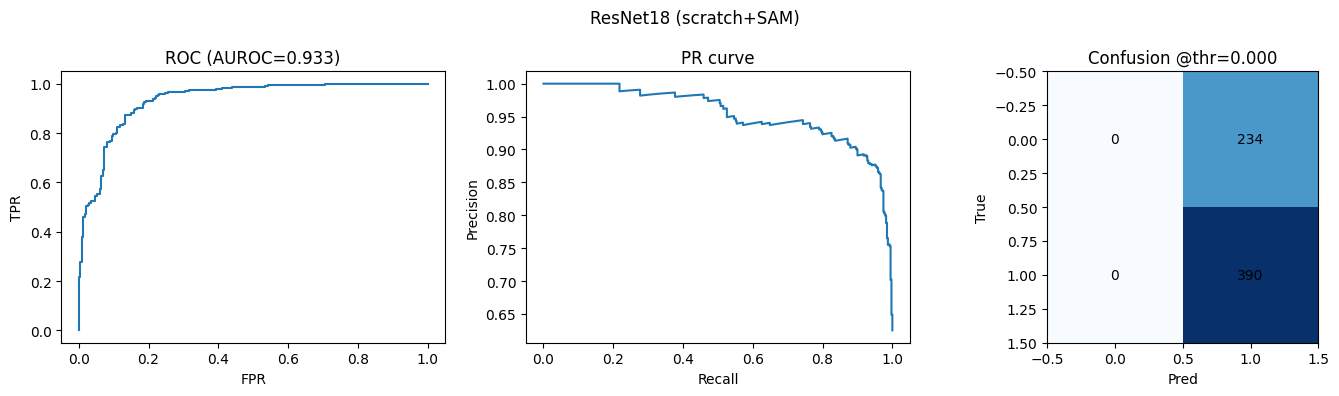

{'summary@0.5': {'acc': 0.8766025641025641,
  'precision': 0.8922305764411027,
  'recall': 0.9128205128205128,
  'f1': 0.9024081115335868,
  'auroc': 0.9333881218496604,
  'thr': 0.5},
 'summary@recall': {'acc': 0.625,
  'precision': 0.625,
  'recall': 1.0,
  'f1': 0.7692307692307693,
  'auroc': 0.9333881218496604,
  'thr': 0.0002508106117602438},
 'threshold': 0.0002508106117602438,
 'time_sec': 3735.9520020484924,
 'params': 11177538}

In [8]:
rn = build_resnet18(in_chans=3, num_classes=2, pretrained=False, conv_stem=False)
t0=time.time()
rn_tr, rn_hist, rn_time = train_model(
    rn, train_loader, val_loader, DEVICE, arch="resnet18",
    epochs=90, base_lr=0.1, weight_decay=1e-3, label_smoothing=0.0,
    use_sam=True, sam_rho=0.05,
    use_cosine=cfg.use_cosine, warmup_epochs=cfg.warmup_epochs, min_lr_mult=cfg.min_lr_mult,
    monitor=cfg.monitor, patience=cfg.patience, clip_grad_norm=cfg.clip_grad_norm,
    class_weights=class_weights, llrd=False, head_lr_mult=cfg.head_lr_mult, use_amp=cfg.use_amp,
    tag="ResNet18-scratch+SAM"
); rn_time=time.time()-t0
plot_curve(rn_hist['tr_loss'], rn_hist['va_loss'], "ResNet18+SAM — Loss")
plot_two_series(rn_hist['va_acc'], "Val Acc", rn_hist['va_f1'], "Val F1", "ResNet18+SAM — Val")
va=evaluate(rn_tr, val_loader, DEVICE)
thr,rec,prec,f1=choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], cfg.target_recall)
te=evaluate(rn_tr, test_loader, DEVICE)
sum_05=summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca=summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[ResNet18-scratch+SAM @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[ResNet18-scratch+SAM @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("ResNet18 (scratch+SAM)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("ResNet18 (scratch+SAM)", rn_tr, sum_05, sum_reca, threshold=thr, time_sec=rn_time)


[ViT-scratch+SAM] epoch 01/100  tr_loss=0.6915  val_loss=0.5641  val_acc=0.8204  val_f1=0.8869  val_auroc=0.8797  (no_improve=0)
[ViT-scratch+SAM] epoch 02/100  tr_loss=0.5987  val_loss=0.4619  val_acc=0.7516  val_f1=0.8060  val_auroc=0.9161  (no_improve=0)
[ViT-scratch+SAM] epoch 03/100  tr_loss=0.5912  val_loss=0.4146  val_acc=0.7682  val_f1=0.8198  val_auroc=0.9149  (no_improve=1)
[ViT-scratch+SAM] epoch 04/100  tr_loss=0.5524  val_loss=0.3821  val_acc=0.8624  val_f1=0.9044  val_auroc=0.9199  (no_improve=0)
[ViT-scratch+SAM] epoch 05/100  tr_loss=0.5382  val_loss=0.3524  val_acc=0.8064  val_f1=0.8533  val_auroc=0.9415  (no_improve=0)
[ViT-scratch+SAM] epoch 06/100  tr_loss=0.5248  val_loss=0.3637  val_acc=0.8038  val_f1=0.8528  val_auroc=0.9330  (no_improve=1)
[ViT-scratch+SAM] epoch 07/100  tr_loss=0.5049  val_loss=0.3522  val_acc=0.8357  val_f1=0.8798  val_auroc=0.9366  (no_improve=2)
[ViT-scratch+SAM] epoch 08/100  tr_loss=0.5101  val_loss=0.3234  val_acc=0.8280  val_f1=0.8718  v

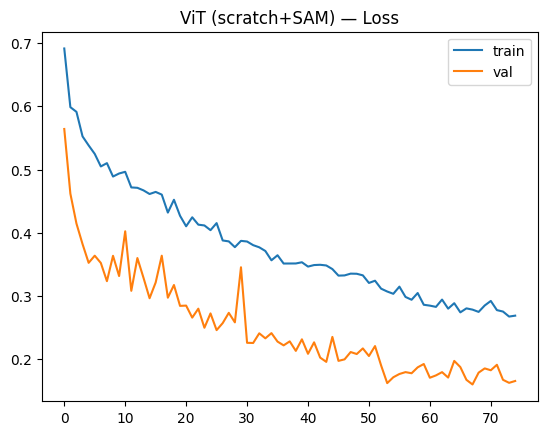

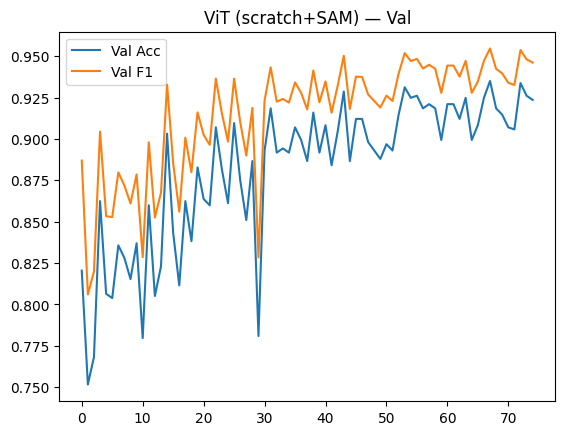

[ViT-scratch+SAM @0.5] {'acc': 0.8782, 'precision': 0.8848, 'recall': 0.9256, 'f1': 0.9048, 'auroc': 0.9401, 'thr': 0.5}
[ViT-scratch+SAM @Rec] {'acc': 0.625, 'precision': 0.625, 'recall': 1.0, 'f1': 0.7692, 'auroc': 0.9401, 'thr': 0.0016}


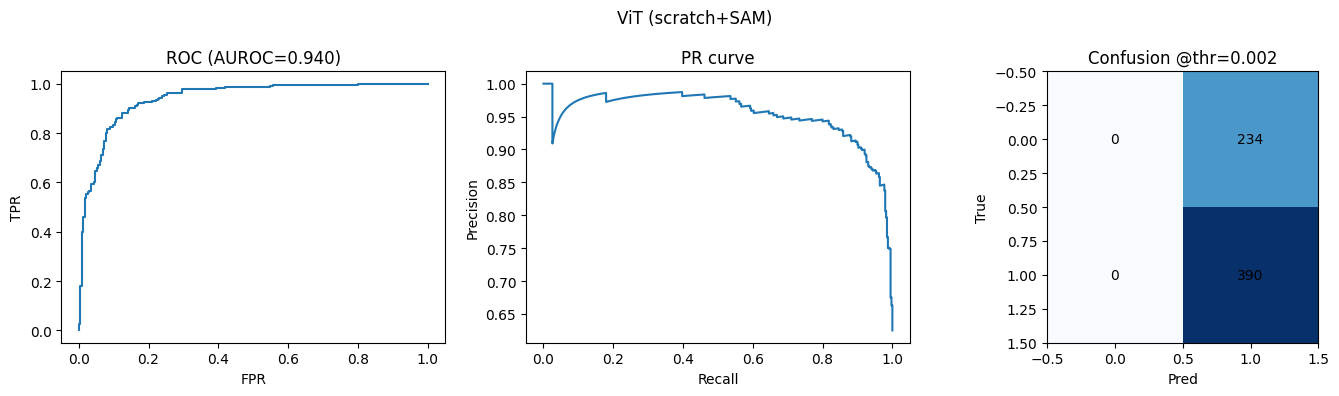

{'summary@0.5': {'acc': 0.8782051282051282,
  'precision': 0.8848039215686274,
  'recall': 0.9256410256410257,
  'f1': 0.9047619047619048,
  'auroc': 0.9400723208415516,
  'thr': 0.5},
 'summary@recall': {'acc': 0.625,
  'precision': 0.625,
  'recall': 1.0,
  'f1': 0.7692307692307693,
  'auroc': 0.9400723208415516,
  'thr': 0.0015643469523638487},
 'threshold': 0.0015643469523638487,
 'time_sec': 16823.949493169785,
 'params': 21666434}

In [ ]:
vit = build_vit_scratch(img_size=224, in_chans=3, num_classes=2,
                        embed_dim=384, depth=12, heads=6, patch=16, mlp_ratio=4.0, drop=0.1)
t0=time.time()
vit_tr, vit_hist, vit_time = train_model(
    vit, train_loader, val_loader, DEVICE, arch="vit",
    epochs=120, base_lr=3e-4, weight_decay=0.3, label_smoothing=0.0,
    use_sam=True, sam_rho=0.2,
    use_cosine=True, warmup_epochs=3, min_lr_mult=0.01,
    monitor="va_auroc", patience=15, clip_grad_norm=1.0,
    class_weights=class_weights, llrd=False, head_lr_mult=10.0, use_amp=False,
    tag="ViT-scratch+SAM"
)
vit_time=time.time()-t0
plot_curve(vit_hist['tr_loss'], vit_hist['va_loss'], "ViT (scratch+SAM) — Loss")
plot_two_series(vit_hist['va_acc'], "Val Acc", vit_hist['va_f1'], "Val F1", "ViT (scratch+SAM) — Val")
va=evaluate(vit_tr, val_loader, DEVICE)
thr,rec,prec,f1=choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], cfg.target_recall)
te=evaluate(vit_tr, test_loader, DEVICE)
sum_05=summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca=summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[ViT-scratch+SAM @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[ViT-scratch+SAM @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("ViT (scratch+SAM)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("ViT (scratch+SAM)", vit_tr, sum_05, sum_reca, threshold=thr, time_sec=vit_time)


In [10]:
import pandas as pd
from src import result_registry as RR
rows=[]
for name,d in RR.items():
    s=d.get("summary@recall", d.get("summary@0.5")); 
    if not s: continue
    thr=d.get("threshold", s.get("thr",0.5))
    rows.append({"Model":name,"Params (M)": round(d.get("params",0)/1e6,2) if d.get("params") else None,
                 "Time (min)": round(d.get("time_sec",0)/60,2) if d.get("time_sec") else None,
                 "Acc":round(s["acc"],4),"Prec":round(s["precision"],4),"Recall":round(s["recall"],4),
                 "F1":round(s["f1"],4),"AUROC":round(s.get("auroc",float('nan')),4),"Thr":round(thr,3)})
df=pd.DataFrame(rows).sort_values(by=["F1","AUROC"], ascending=False).reset_index(drop=True)
display(df); print(df.to_string(index=False))


,Model,Params (M),Time (min),Acc,Prec,Recall,F1,AUROC,Thr
0,ViT (scratch+SAM),21.67,280.40,0.625,0.625,1.0,0.7692,0.9401,0.002
1,ResNet18 (scratch+SAM),11.18,62.27,0.625,0.625,1.0,0.7692,0.9334,0.000
2,CustomCNN (scratch+SAM),0.48,96.52,0.625,0.625,1.0,0.7692,0.9026,0.000


                  Model  Params (M)  Time (min)   Acc  Prec  Recall     F1  AUROC   Thr
      ViT (scratch+SAM)       21.67      280.40 0.625 0.625     1.0 0.7692 0.9401 0.002
 ResNet18 (scratch+SAM)       11.18       62.27 0.625 0.625     1.0 0.7692 0.9334 0.000
CustomCNN (scratch+SAM)        0.48       96.52 0.625 0.625     1.0 0.7692 0.9026 0.000
